# Summary statistics and SBI methods

In the `sbi` workflow, a simulator generates data $x$ for a parameter vector $\theta$. We sample parameters from the prior and simulate the corresponding observations to construct training pairs $(\theta_i, x_i)$. A neural density estimator, such as a normalizing flow, then learns the conditional posterior $p(\theta\mid x)$.

Simulator outputs can be high-dimensional—for example, RGB images or time-dependent trajectories. Training directly on these data may require larger networks and many more simulations.

In this notebook, we compress the data into lower-dimensional *summary statistics* and use them as inputs to the posterior estimator.

## Molecular dynamics simulator


In this example, we use a one-dimensional molecular dynamics simulator containing four argon atoms. They interact through the [Lennard–Jones potential](https://en.wikipedia.org/wiki/Lennard-Jones_potential), which contains attractive and repulsive terms:

$$
V(r) = 4 \epsilon\left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6\right].
$$

The force is the negative gradient of the potential. Its magnitude is
$$
\|\vec{F}(r)\| = 48 \epsilon  \sigma^{12} / r^{13} - 24  \epsilon  \sigma^{6}/r^7,
$$
where the direction has been omitted, but is along the line connecting both interacting particles. Since we have an analytical description for the force, it is now possible to use [Newton's laws of motion](https://en.wikipedia.org/wiki/Newton%27s_laws_of_motion) to get the acceleration, velocity, and position of each particle at any given time for a given set of initial conditions. A simulator that solves Newton's equations is provided in the [./simulators/md.py](./simulators/md.py) module. If you are interested in the details, feel free to look at the source code, it is a slightly modified version of an implementation that can be found in [Python Chemistry](https://pythoninchemistry.org/sim_and_scat/molecular_dynamics/build_an_md).


In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline

import pickle
from scipy.signal import find_peaks
import os
import sys
from pathlib import Path

# sbi related
import sbi.utils as utils
from sbi.inference import NPE_C, simulate_for_sbi
from sbi.analysis import pairplot
from sbi.utils.user_input_checks import (
    process_prior,
    process_simulator,
) 
from sbi.utils.sbiutils import seed_all_backends

# Locate the repository independently of whether Jupyter was started from
# the repository root or from the notebooks directory.
repo_candidates = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next((path for path in repo_candidates
                  if (path / "notebooks" / "simulators").is_dir()
                  and (path / "data").is_dir()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not locate the sbi_intro repository root.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Bring in the one-dimensional molecular-dynamics simulator.
from notebooks.simulators.md import run_md

num_cpus = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1))
workers = min(8, num_cpus)
print(f"Found {num_cpus} available CPU cores. Will use {workers} workers.")
seed_all_backends(24)

Found 10 available CPU cores. Will use 8 workers.


Inspect the simulator's inputs and output:

In [23]:
run_md?

Signature:
run_md(
    dt,
    number_of_steps,
    x,
    initial_temp,
    epsilon,
    sigma,
    box_length=20,
    seed=None,
)
Docstring:
Run a molecular dynamics (MD) simulation using the velocity Verlet algorithm.

Parameters
----------
dt : float
    The timestep length (s).
number_of_steps : int
    Number of iterations in the simulation.
x : ndarray of floats
    The initial positions of the particles in a single dimension (Å).
initial_temp : float
    Temperature of the system at initialization (K).
epsilon : float
    Depth of the potential well in the Lennard-Jones potential (energy units).
sigma : float
    Finite distance at which the inter-particle potential is zero (Å).
box_length : float, optional, default=20
    Length of the simulation box (Å).
seed : int, optional, default=None
    Random seed for reproducibility.

Returns
-------
positions : ndarray of floats
    The positions of all particles at each timestep of the simulation (Å).
    Shape: (number_of_steps, n

A simulation is defined by the Lennard–Jones parameters $\epsilon$ and $\sigma$, the initial particle positions $\vec{x}_0$, the initial temperature, and the time step.

#### Observed data
Now, let's suppose we observed (measured) the trajectories of 4 atoms in a one-dimensional box of length 20 Å for 800 simulation-time units. We use simulation-time units here because this simplified teaching simulator does not perform a complete conversion to physical time units. Let's load the measured data and inspect it.

In [24]:
with open(REPO_ROOT / "data" / "observation_free.pkl", "rb") as pf:
    t, x_truth = pickle.load(pf)

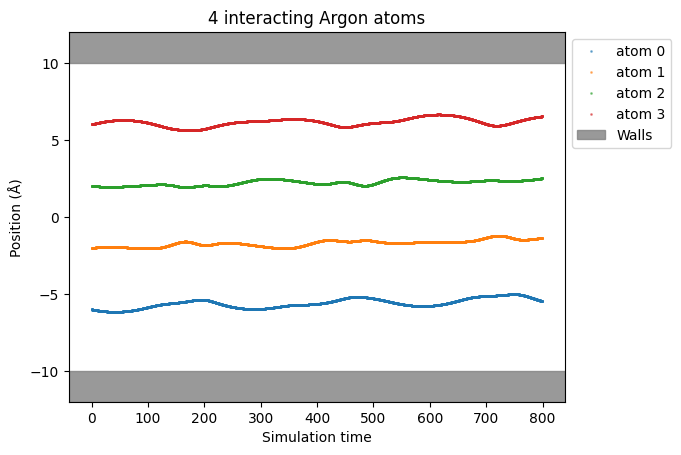

In [25]:
# we know the length of our box
box_length = 20

# plot the measured data
for i in range(0, x_truth.shape[1]):
    plt.plot(t, x_truth[:, i], 'o', ms=1, label=f"atom {i}", alpha=0.5)
plt.ylim(-box_length * 0.6, box_length * 0.6)
plt.axhspan(box_length/2, plt.ylim()[1], color='gray', alpha=0.8, label="Walls")
plt.axhspan(plt.ylim()[0], -box_length/2, color='gray', alpha=0.8)
plt.legend(bbox_to_anchor=(1,1))
plt.xlabel("Simulation time")
plt.ylabel("Position (Å)")
plt.title("4 interacting Argon atoms")
plt.show()

The trajectories contain information about the interaction potential. We treat the measured initial positions as fixed and infer the potential parameters and initial temperature. Experiment with these parameters to understand their effects and choose reasonable prior bounds.

In [26]:
# get initial positions
x0 = x_truth[0, :]

# get timestep
dt = t[1] - t[0]

Temperature is measured in kelvin (300 K is approximately room temperature). In the Lennard–Jones potential, $\epsilon$ is an energy measured in electronvolts (eV), while $\sigma$, the particle positions, and the box length are measured in ångströms (Å).

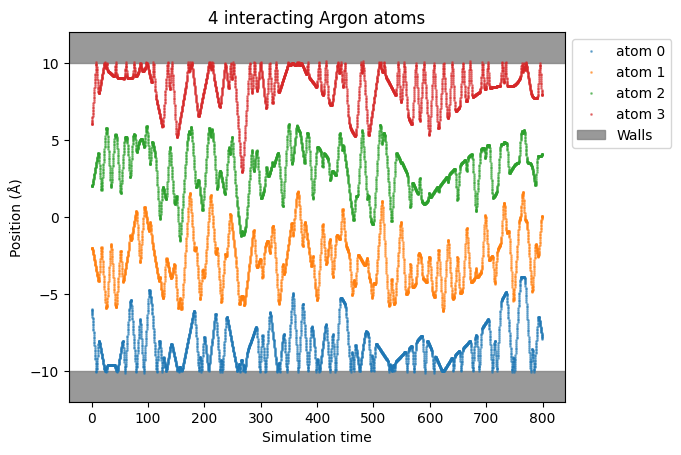

In [27]:
def create_x(theta):
        T, epsilon, sigma = theta.numpy()
        return run_md(dt, len(t), x0, T, epsilon, sigma, box_length=box_length)

def plot_single(theta):
    x = create_x(theta)
    for i in range(0, x_truth.shape[1]):
        plt.plot(t, x[:, i], 'o', ms=1, label=f"atom {i}", alpha=0.5)
    plt.ylim(-box_length * 0.6, box_length * 0.6)
    plt.axhspan(box_length/2, plt.ylim()[1], color='gray', alpha=0.8, label="Walls")
    plt.axhspan(plt.ylim()[0], -box_length/2, color='gray', alpha=0.8)
    plt.legend(bbox_to_anchor=(1,1))
    plt.xlabel("Simulation time")
    plt.ylabel("Position (Å)")
    plt.title("4 interacting Argon atoms")
    plt.show()

T = 100 # Kelvin
epsilon = 0.1 # eV
sigma = 5 # Å

theta_test = torch.tensor([T, epsilon, sigma])
plot_single(theta_test)

### Introduction to summary statistics

Feeding complete trajectories into a posterior estimator creates a large input space and may require a more complex network and more training simulations. Summary statistics instead compress each trajectory into a smaller set of informative quantities.

For this problem, higher temperatures tend to produce faster fluctuations, while the potential parameters affect how closely particles approach one another. This motivates the following summaries:

- **Mean pairwise distances:** Four atoms define $(4 \times 3)/2 = 6$ distinct pairs. Their time-averaged distances may be informative about the potential parameters.

- **Mean kinetic-energy proxy:** Finite differences of the positions provide velocity estimates. Averaging one half of the summed squared velocities over time yields one quantity.

- **Fluctuation counts:** Applying `find_peaks` to each particle's squared deviation from its mean position yields four peak counts.

Therefore, for a given $\theta=(T,\epsilon,\sigma)$, we obtain an 11-dimensional vector that summarizes the $4000 \times 4 = 16000$ position values in one trajectory.

In [28]:
def pairwise_distances(x):
    """
    Calculate pairwise distances between particles in a 2D array of positions.
    
    Args:
        x (numpy.ndarray): 2D array of positions of the particles in the simulation.
    """
    n = x.shape[1]
    i, j = np.triu_indices(n, k=1)
    distances = np.abs(x[:, i] - x[:, j])
    return distances

def calculate_average_energy(dt, x):
    """
    Calculate the average kinetic energy of a system of particles.
    
    Args:
        dt (float): Time step of the molecular dynamics simulation.
        x (numpy.ndarray): 2D array of positions of the particles in the simulation.
    
    Returns:
        float: Average kinetic energy of the system.
    """
    v = np.diff(x, axis=0)/dt # shape becomes (9999, 4)
    KE = 1./2. * np.sum(v**2, axis=1) # shape becomes (9999,)
    average_energy = np.mean(KE)
    return average_energy

def summarize_trajectory(x):
    """Compress one trajectory into the 11 summary statistics used by NPE."""
    avg_pairwise_distance = pairwise_distances(x).mean(axis=0)
    num_cp = np.array(
        [len(find_peaks(i)[0]) for i in ((x - x.mean(axis=0)) ** 2).T]
    )
    average_energy = np.array([calculate_average_energy(dt, x)])
    return np.concatenate([avg_pairwise_distance, num_cp, average_energy])

def create_summary(theta):
    """
    Calculate summary statistics of a molecular dynamics simulation.
    
    Args:
        theta (numpy.ndarray): Parameter values of the molecular dynamics simulation.
    
    Returns:
        numpy.ndarray: 1D array of summary statistics, in the order of pairwise distances,
        number of peaks, and average kinetic energy.
    """
    T, epsilon, sigma = theta.numpy()
    x = run_md(dt, len(t), x0, T, epsilon, sigma, box_length=box_length)
    return summarize_trajectory(x)

Evaluate the summary function at the test parameter vector:

In [29]:
summary_test = create_summary(theta_test)
print(summary_test)
print(summary_test.size)

[  5.55729041  11.42698631  16.99287648   5.86969589  11.43558606
   5.56589017 100.          82.          82.          93.
   0.26748508]
11


We begin the `sbi` workflow by defining a prior over the three parameters.

In [30]:
prior_min = torch.as_tensor([1e-3, 0.005, 1.6])
prior_max = torch.as_tensor([2000.0, 0.05, 5.0])
prior = utils.BoxUniform(
        low=prior_min, high=prior_max
    )

Select a training device according to the available hardware:

In [31]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

prior.to(device)

Next, validate and prepare the simulator and prior:

In [32]:
# simulate in the cpu, multiple cores
prior.to("cpu")
prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulate_x = process_simulator(create_x, prior, prior_returns_numpy)

Generate an initial set of trajectories. Runtime depends on the available hardware; this simulation stage can benefit from parallel computing resources.

In [33]:
%%time
theta_traj, x_traj = simulate_for_sbi(
    simulate_x, prior, num_simulations=1000, num_workers=workers
)

100%|██████████| 1000/1000 [00:25<00:00, 39.99it/s]


CPU times: user 3.32 s, sys: 200 ms, total: 3.52 s
Wall time: 25.1 s


Plot a subset of the simulated trajectories. The broad prior produces both rapidly fluctuating and comparatively smooth trajectories.

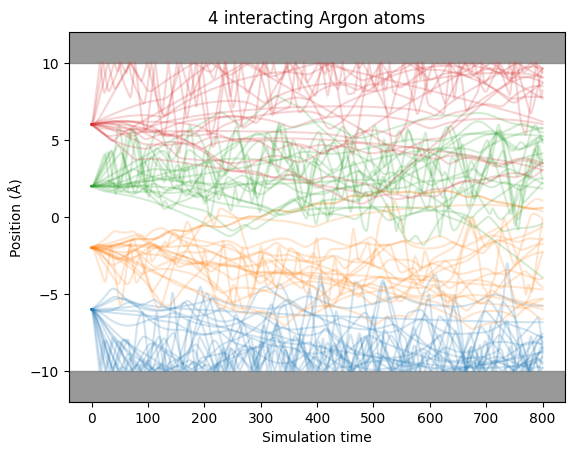

In [34]:
for i, ci in zip(range(0, x_traj.shape[2]), mcolors.TABLEAU_COLORS):
    for j in range(20):
        plt.plot(t, x_traj[np.random.choice(1000), :, i], color=ci, alpha=0.2)
plt.ylim(-box_length * 0.6, box_length * 0.6)
plt.axhspan(10, plt.ylim()[1], color='gray', alpha=0.8)
plt.axhspan(plt.ylim()[0], -10, color='gray', alpha=0.8)
plt.xlabel("Simulation time")
plt.ylabel("Position (Å)")
plt.title("4 interacting Argon atoms")
plt.show()

For inference with summary statistics, each simulated trajectory must be compressed. Pass `create_summary` to `process_simulator` so that simulations return summaries directly:

In [35]:
simulate_summary = process_simulator(create_summary, prior, prior_returns_numpy)

Calculate the same summary statistics for the observed trajectory:

In [36]:
# Apply exactly the same compression to the observed trajectory.
x_summary_o = torch.as_tensor(summarize_trajectory(x_truth), dtype=torch.float32)


We now generate parameter–summary pairs and train a neural density estimator for $p(\theta\mid s(x))$. Here we use sequential neural posterior estimation (`NPE_C`) with two rounds.

In [37]:
# train NN
prior.to(device)
inference = NPE_C(prior=prior, density_estimator="nsf", device=device)

proposal = prior
n_samples = 5000
num_rounds=2
for i in range(num_rounds):
    print(f"Round {i+1}")
    proposal.to("cpu")
    theta, x_summary = simulate_for_sbi(
        simulate_summary, proposal, num_simulations=n_samples, num_workers=workers
    )
    proposal.to(device)
    density_estimator = inference.append_simulations(theta.to(device),
                                                 x_summary.to(device),
                                                proposal=proposal,
                                                exclude_invalid_x=True).train(training_batch_size=1024,
                                                                              learning_rate=0.01,
                                                                              show_train_summary=True)
    posterior = inference.build_posterior(density_estimator)
    proposal = posterior.set_default_x(x_summary_o)

Round 1


100%|██████████| 5000/5000 [02:09<00:00, 38.54it/s]


 Neural network successfully converged after 78 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 78
        Best validation performance: 3.2194
        -------------------------
        
Round 2


Drawing 5000 posterior samples for 1 observations: 5054it [00:00, 195182.70it/s]           
100%|██████████| 5000/5000 [02:14<00:00, 37.04it/s]


Using SNPE-C with atomic loss
 Neural network successfully converged after 41 epochs.
        -------------------------
        ||||| ROUND 2 STATS |||||:
        -------------------------
        Epochs trained: 41
        Best validation performance: 0.7573
        -------------------------
        


Move the trained posterior to the CPU for sampling. If training already used the CPU, this has no practical effect.

In [38]:
posterior.to("cpu")

Condition the trained posterior on the observed summary and draw parameter samples:

In [39]:
theta_p = posterior.sample((10000,), x=x_summary_o)

Drawing 10000 posterior samples for 1 observations: 11623it [00:00, 116222.08it/s]           


Because this is a synthetic example, we know the parameter values used to generate the observation and can compare them with the inferred posterior:

In [40]:
# The generating parameters are usually unknown for real observations.
theta_o = (600, 0.0103, 3.4)

Plot the posterior samples together with the generating parameters:

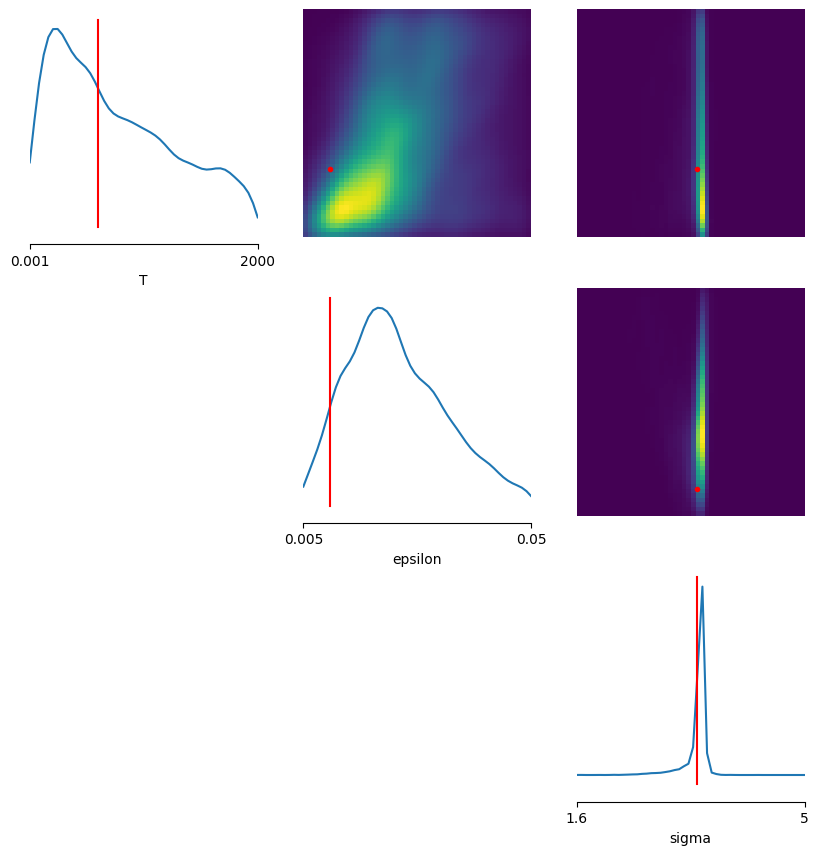

In [41]:
fig, axes = pairplot(
        theta_p,
        limits=list(zip(prior_min, prior_max)),
        ticks=list(zip(prior_min, prior_max)),
        fig_kwargs={
            #"figsize": (7, 7),
            "points_offdiag": {"markersize": 6},
            "points_colors": "r",
        },
        labels=["T", "epsilon", "sigma"],
        upper="kde",
        diag="kde",
        points=theta_o,
    )
plt.show()

### Posterior predictive check

The pair plot above evaluates **parameter recovery** because the generating parameters are known in this synthetic example. A posterior predictive check (PPC) asks a different and more generally applicable question: *Can parameter values drawn from the inferred posterior generate data that resemble the observation?*

For each posterior draw $\theta^{(m)}$, we generate a replicated trajectory

$$\theta^{(m)} \sim p(\theta\mid s(x_o)), \qquad x_{\mathrm{rep}}^{(m)} \sim p(x\mid\theta^{(m)}).$$

We then compare the replicated trajectories and their summaries with the observed data. Agreement indicates that the inferred parameters can reproduce the aspects of the data being checked. Systematic disagreement can reveal inadequate summaries, an inaccurate posterior estimator, or a misspecified simulator. A PPC does not prove that the posterior is correct, and it cannot identify which of these causes is responsible for a mismatch.

In [42]:
# Draw posterior parameters and generate replicated trajectories in parallel.
num_ppc = 100
theta_ppc, x_ppc_tensor = simulate_for_sbi(
    simulate_x, posterior, num_simulations=num_ppc, num_workers=workers
)
x_ppc = x_ppc_tensor.numpy()
summary_ppc = np.stack([summarize_trajectory(x) for x in x_ppc])

x_ppc.shape, summary_ppc.shape

Drawing 100 posterior samples for 1 observations: 142it [00:00, 22285.08it/s]            
100%|██████████| 100/100 [00:02<00:00, 35.58it/s]


((100, 4000, 4), (100, 11))

First compare the complete trajectories. The shaded region is the central 90% posterior predictive interval and the line is its median. The observed trajectory should generally lie within this band, although pointwise coverage alone is not a formal test.

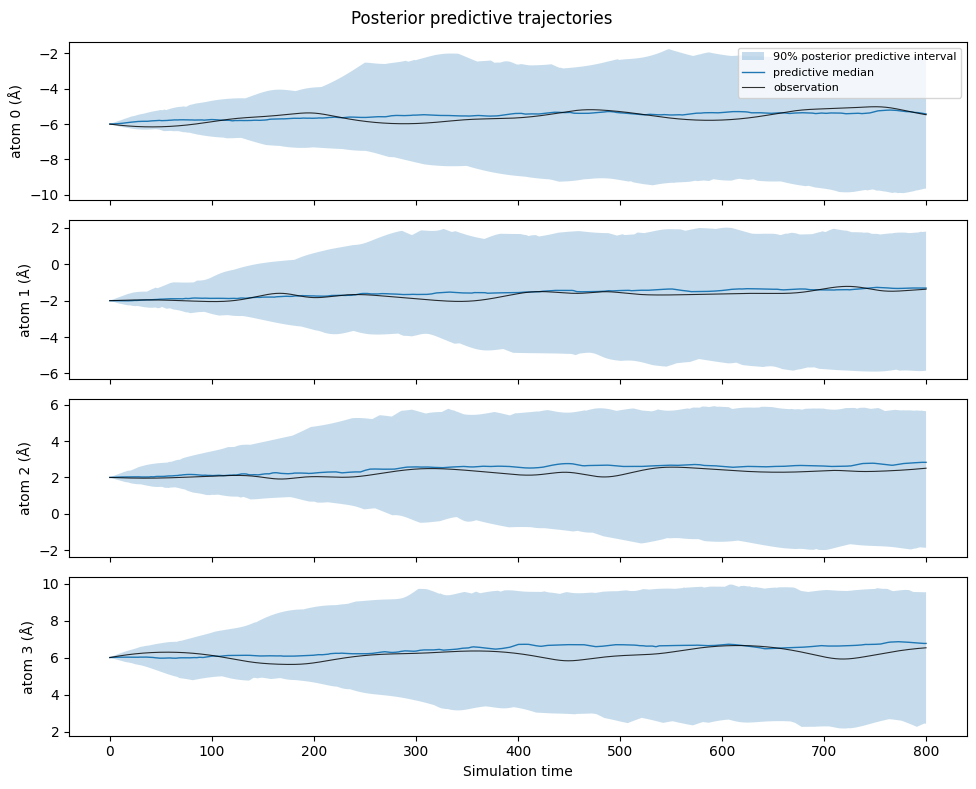

In [43]:
lower, median, upper = np.quantile(x_ppc, [0.05, 0.5, 0.95], axis=0)

fig, axes = plt.subplots(x_truth.shape[1], 1, figsize=(10, 8), sharex=True)
for atom, ax in enumerate(axes):
    ax.fill_between(t, lower[:, atom], upper[:, atom], alpha=0.25,
                    label="90% posterior predictive interval")
    ax.plot(t, median[:, atom], lw=1, label="predictive median")
    ax.plot(t, x_truth[:, atom], color="black", lw=0.8, alpha=0.8,
            label="observation")
    ax.set_ylabel(f"atom {atom} (Å)")
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Simulation time")
fig.suptitle("Posterior predictive trajectories")
fig.tight_layout()
plt.show()

Because inference was conditioned on the 11 summaries, we should also inspect them directly. Each box shows the posterior predictive distribution of one statistic; the red marker is its observed value. An observed statistic far into a predictive tail signals a mismatch. Close agreement is expected here, but does not guarantee that unrecorded features of the full trajectories are reproduced.

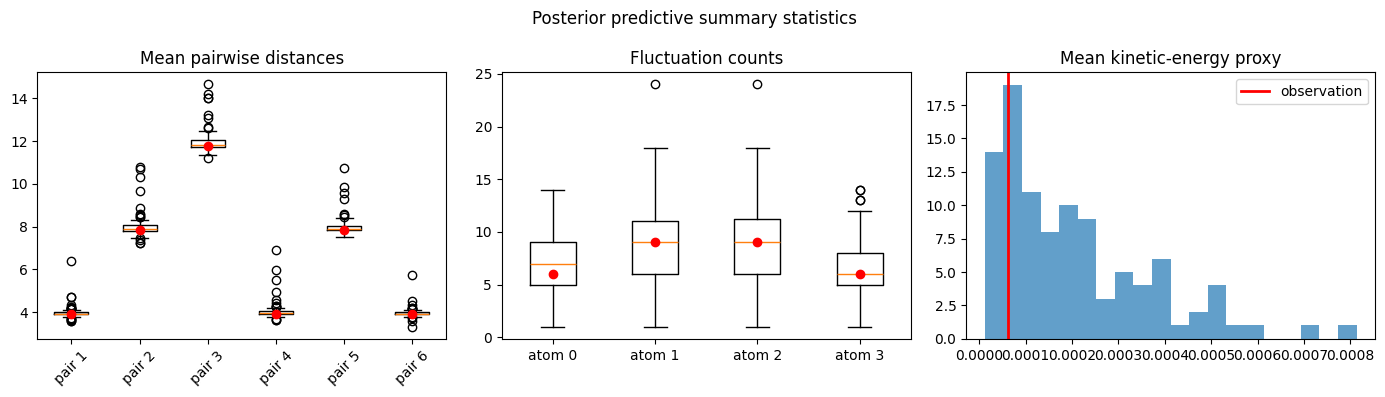

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].boxplot(summary_ppc[:, :6], tick_labels=[f"pair {i+1}" for i in range(6)])
axes[0].scatter(np.arange(1, 7), x_summary_o[:6], color="red", zorder=3)
axes[0].set_title("Mean pairwise distances")
axes[0].tick_params(axis="x", rotation=45)

axes[1].boxplot(summary_ppc[:, 6:10], tick_labels=[f"atom {i}" for i in range(4)])
axes[1].scatter(np.arange(1, 5), x_summary_o[6:10], color="red", zorder=3)
axes[1].set_title("Fluctuation counts")

axes[2].hist(summary_ppc[:, 10], bins=20, alpha=0.7)
axes[2].axvline(x_summary_o[10], color="red", lw=2, label="observation")
axes[2].set_title("Mean kinetic-energy proxy")
axes[2].legend()

fig.suptitle("Posterior predictive summary statistics")
fig.tight_layout()
plt.show()

### Conclusion

Using `sbi`, we inferred the Lennard–Jones parameters and initial temperature from hand-crafted summaries of the simulated trajectories. These summaries inject domain knowledge and greatly reduce the input dimension, but they may also discard information. Alternative or additional summaries could improve the inference; this example demonstrates the basic workflow.